In [9]:
import matplotlib.pyplot as plt
import csv
from PIL import Image
import numpy as np
import os
import pickle
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from skimage.color import rgb2gray
from skimage import exposure
from collections import OrderedDict

In [ ]:
# Column indices in the CSV file for the 4 outputs 
X_COL, Y_COL, XW_COL, YW_COL = 1, 2, 3, 4 
RANDOM_STATE = 42 # For reproducibility
TEST_SIZE_RATIO = 0.3 # Use 30% of the 150 images for the 'test' set

1. Load and Preprocess Data

In [ ]:
images = []
all_outputs = []
rootpath = 'Training'
prefix = rootpath + '/' 

try:
    with open(prefix + 'myData'+ '.csv', 'r') as gtFile:
        gtReader = csv.reader(gtFile, delimiter=';')
        next(gtReader) # Skip header row
        
        for row in gtReader:
            if not row or len(row) <= YW_COL:
                continue
            
            # Image Loading
            img_path = prefix + row[0]
            img = Image.open(img_path)

            # Resize to 32x32
            img = img.resize((32, 32), Image.BICUBIC) 
            img_array = np.array(img)

            # Convert to grayscale
            gray_img = rgb2gray(img_array)
            
            # Apply CLAHE (Contrast Enhancement)
            clache_img = exposure.equalize_adapthist(gray_img, clip_limit=0.03)
            
            images.append(clache_img) 
            
            # Read all 4 outputs 
            x = int(row[X_COL])
            y = int(row[Y_COL])
            xw = int(row[XW_COL])
            yw = int(row[YW_COL])
            all_outputs.append([x, y, xw, yw])

except FileNotFoundError:
    print(f"Error: Training file not found at {prefix + 'myData.csv'}")
    exit()
except Exception as e:
    print(f"Skipping row due to error: {e}")
    
Y_data = np.array(all_outputs)
raw_images = images

print(f'Total number of samples loaded: {len(Y_data)}')

X_data = []
for img in raw_images:
    X_data.append(img.flatten())
X_data = np.array(X_data)

print(f'Shape of feature matrix X: {X_data.shape}')

Total number of samples loaded: 150
Shape of feature matrix X: (150, 1024)


3. Split Data to be Training and Validation Sets

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X_data, Y_data, test_size=TEST_SIZE_RATIO, random_state=RANDOM_STATE
)
print(f'Training samples: {len(X_train)}, Validation samples: {len(X_test)}')

Training samples: 105, Validation samples: 45


4. n_estimator Testing


Running MSE vs. Estimators Analysis...


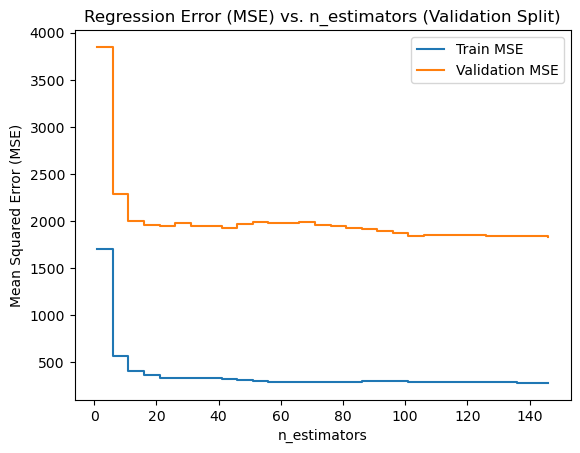

In [ ]:
min_estimators = 1
max_estimators = 150
train_mse_scores = []
test_mse_scores = []

print("\nRunning MSE vs. Estimators Analysis...")

# Initialize the model once for warm_start 
rf_regressor = RandomForestRegressor(n_estimators=1, random_state=RANDOM_STATE)

# Iterate through the estimator range (step of 5)
for i in range(min_estimators, max_estimators + 1, 5):
    rf_regressor.set_params(n_estimators=i)
    rf_regressor.fit(X_train, Y_train)
    
    # Predict and calculate MSE for training set
    Y_train_pred = rf_regressor.predict(X_train)
    train_mse = mean_squared_error(Y_train, Y_train_pred)
    train_mse_scores.append(train_mse)

    # Predict and calculate MSE for validation set
    Y_test_pred = rf_regressor.predict(X_test)
    test_mse = mean_squared_error(Y_test, Y_test_pred)
    test_mse_scores.append(test_mse)

# Plotting the MSE vs. estimators
fig, ax = plt.subplots(dpi = 100)
ax.set_xlabel("n_estimators")
ax.set_ylabel("Mean Squared Error (MSE)")
ax.set_title("Regression Error (MSE) vs. n_estimators (Validation Split)")
ax.plot(range(min_estimators, max_estimators + 1, 5), train_mse_scores, label="Train MSE", drawstyle="steps-post")
ax.plot(range(min_estimators, max_estimators + 1, 5), test_mse_scores, label="Validation MSE", drawstyle="steps-post")
ax.legend()
plt.show()

5. max_features Testing


Running OOB Error Rate Analysis...


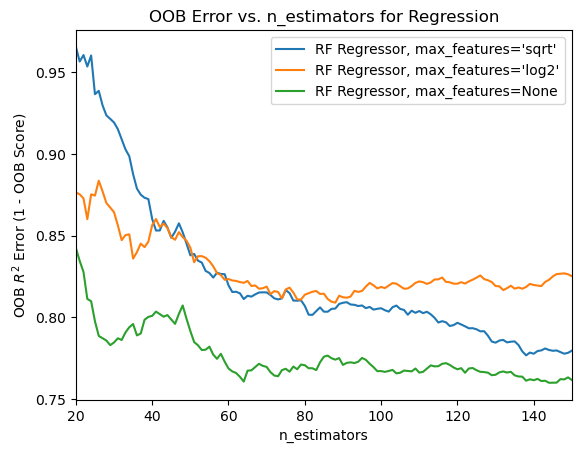

In [ ]:
ensemble_regressors = [
    ("RF Regressor, max_features='sqrt'",
        RandomForestRegressor(warm_start=True, oob_score=True, max_features="sqrt", random_state=RANDOM_STATE)),
    ("RF Regressor, max_features='log2'",
        RandomForestRegressor(warm_start=True, oob_score=True, max_features='log2', random_state=RANDOM_STATE)),
    ("RF Regressor, max_features=None",
        RandomForestRegressor(warm_start=True, oob_score=True, max_features=None, random_state=RANDOM_STATE))
]

# Map a regressor name to a list of (n_estimators, error rate) pairs.
oob_error_rate = OrderedDict((label, []) for label, _ in ensemble_regressors)

min_estimators = 20 # Start at 20 as OOB needs enough trees to stabilize
max_estimators = 150

print("\nRunning OOB Error Rate Analysis...")

for label, reg in ensemble_regressors:
    # Warm start: train sequentially, adding one estimator at a time
    for i in range(min_estimators, max_estimators + 1):
        reg.set_params(n_estimators=i)
        
        # Use n_jobs=1 because warm_start is not fully compatible with multi-threading
        reg.fit(X_train, Y_train) 

        # Record the OOB error for each n_estimators=i setting (1 - R^2).
        oob_error = 1 - reg.oob_score_ 
        oob_error_rate[label].append((i, oob_error))

plt.figure(dpi=100)
# Generate the "OOB Error" vs. "n_estimators" plot.
for label, reg_err in oob_error_rate.items():
    xs, ys = zip(*reg_err)
    plt.plot(xs, ys, label=label)

plt.xlim(min_estimators, max_estimators)
plt.xlabel("n_estimators")
plt.ylabel("OOB $R^2$ Error (1 - OOB Score)")
plt.title("OOB Error vs. n_estimators for Regression")
plt.legend(loc="upper right")
plt.show()